In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/ML/Dummy data set/Per_Trail_EEG-3.xlsx")

In [ ]:
# Convert ASD/TD to 1/0 for ML
df['Label_Class'] = df['DataSet'].apply(
    lambda x: 1 if pd.notna(x) and 'ASD' in x else (0 if pd.notna(x) and 'TD' in x else None)
)

# Select features
features = [
    'AF7_Alpha', 'AF7_Beta', 'AF7_Theta',
    'AF8_Alpha', 'AF8_Beta', 'AF8_Theta',
    'Theta/Alpha_AF7', 'Alpha/Beta_AF7',
    'Theta/Alpha_AF8', 'Alpha/Beta_AF8'
]

X = df[features]
y = df['Label_Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


#  Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 🔍 GridSearchCV to tune SVM
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

svm = SVC(probability=True, random_state=42)

grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("✅ Best Hyperparameters:", grid.best_params_)
print("🏆 Best Cross-Validated Accuracy: {:.2f}".format(grid.best_score_))

best_svm_model = grid.best_estimator_


✅ Best Hyperparameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
🏆 Best Cross-Validated Accuracy: 0.89


✅ Best K = 3 with accuracy = 0.83


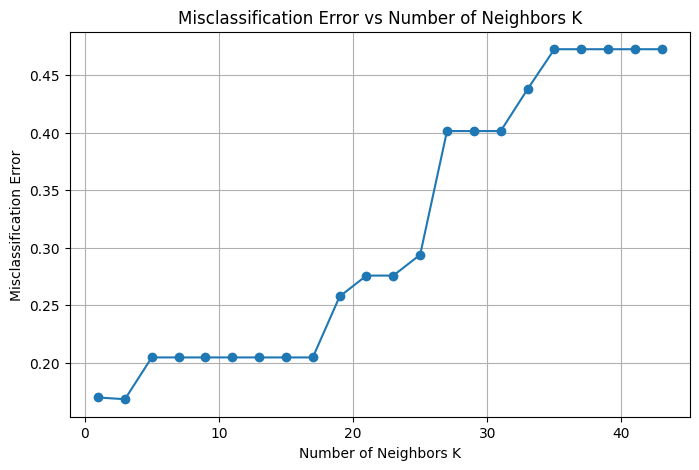

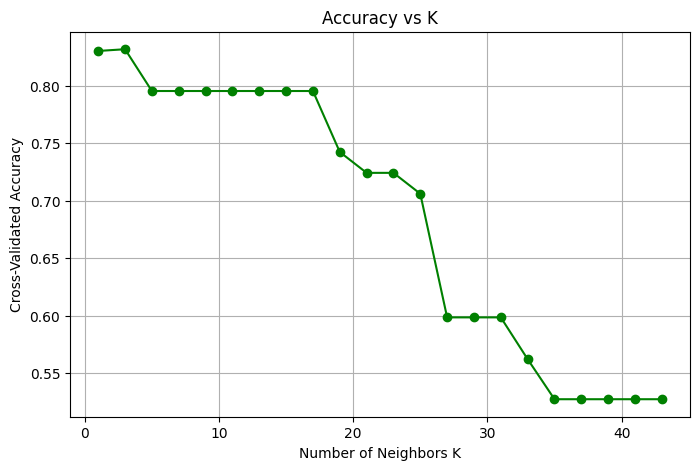

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define safe K range based on your dataset ---
total_samples = len(X)
max_safe_k = (total_samples * 4) // 5  # 80% of data for training in 5-fold CV
k_range = list(range(1, max_safe_k, 2))  # Odd K values only

# Store accuracy and misclassification error ---
accuracy_scores = []
error_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    accuracy_scores.append(mean_score)
    error_scores.append(1 - mean_score)

# Get best K based on highest accuracy ---
best_k = k_range[np.argmax(accuracy_scores)]
print(f"✅ Best K = {best_k} with accuracy = {max(accuracy_scores):.2f}")

# Plot Misclassification Error ---
plt.figure(figsize=(8, 5))
plt.plot(k_range, error_scores, marker='o')
plt.xlabel("Number of Neighbors K")
plt.ylabel("Misclassification Error")
plt.title("Misclassification Error vs Number of Neighbors K")
plt.grid(True)
plt.show()

#  Plot Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, accuracy_scores, marker='o', color='green')
plt.xlabel("Number of Neighbors K")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.show()

# Define KNN with best K for final model evaluation
knn_model = KNeighborsClassifier(n_neighbors=best_k)


✅ Best K = 3 with average accuracy = 0.83


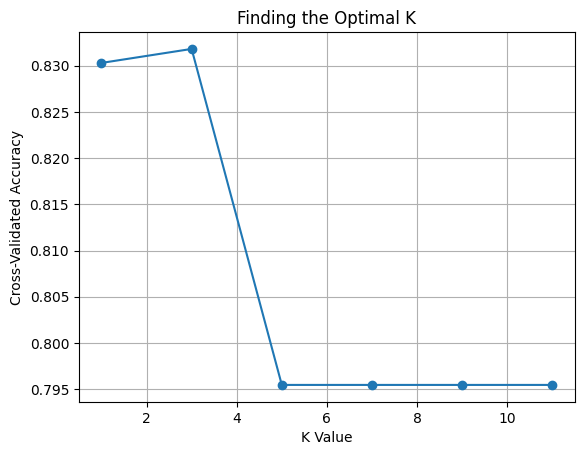

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Use full X and y (not split) for cross-validation
k_values = [1, 3, 5, 7, 9, 11]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"✅ Best K = {best_k} with average accuracy = {max(cv_scores):.2f}")

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('K Value')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Finding the Optimal K')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Define individual models
svm_model = best_svm_model
knn_model = KNeighborsClassifier(n_neighbors=best_k)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define ensemble model
ensemble_model = VotingClassifier(estimators=[
    ('SVM', svm_model),
    ('KNN', knn_model),
    ('RF', rf_model)
], voting='soft')

# Store all models in dictionary
models = {
    "SVM": svm_model,
    "KNN": knn_model,
    "Random Forest": rf_model,
    "Ensemble": ensemble_model
}

# Function to calculate task-wise accuracy
def task_wise_accuracy(y_pred, model_name):
    X_test_copy = X_test.copy()
    X_test_copy['true_label'] = y_test.values
    X_test_copy['predicted_label'] = y_pred
    X_test_copy['task_type'] = df.loc[X_test.index, 'Label']
    X_test_copy['group'] = df.loc[X_test.index, 'Label_Class']

    task_group_accuracy = X_test_copy.groupby(['group', 'task_type']).apply(
        lambda g: (g['true_label'] == g['predicted_label']).mean()
    ).unstack(level=1)

    task_group_accuracy.index = task_group_accuracy.index.map({0: 'TD', 1: 'ASD'})
    task_group_accuracy.columns = ['Task 0', 'Task 1', 'Task 2']

    print(f"🎯 Task-wise Accuracy Within Each Group ({model_name}):\n", task_group_accuracy)


# Evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\n===== {name} Classification Report =====")
    print(classification_report(y_test, y_pred, target_names=['TD', 'ASD'], zero_division=0))

    task_wise_accuracy(y_pred, name)


===== SVM Classification Report =====
              precision    recall  f1-score   support

          TD       1.00      0.67      0.80         6
         ASD       0.75      1.00      0.86         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12

🎯 Task-wise Accuracy Within Each Group (SVM):
        Task 0    Task 1  Task 2
group                          
TD        1.0  0.333333     1.0
ASD       1.0  1.000000     1.0

===== KNN Classification Report =====
              precision    recall  f1-score   support

          TD       0.60      1.00      0.75         6
         ASD       1.00      0.33      0.50         6

    accuracy                           0.67        12
   macro avg       0.80      0.67      0.62        12
weighted avg       0.80      0.67      0.62        12

🎯 Task-wise Accuracy Within Each Group (KNN):
        Task 0  Task 1    Task 2
group         

<ipython-input-37-3965146556>:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  task_group_accuracy = X_test_copy.groupby(['group', 'task_type']).apply(
<ipython-input-37-3965146556>:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  task_group_accuracy = X_test_copy.groupby(['group', 'task_type']).apply(
<ipython-input-37-3965146556>:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping co


===== Ensemble Classification Report =====
              precision    recall  f1-score   support

          TD       0.86      1.00      0.92         6
         ASD       1.00      0.83      0.91         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12

🎯 Task-wise Accuracy Within Each Group (Ensemble):
        Task 0  Task 1  Task 2
group                        
TD        1.0     1.0     1.0
ASD       1.0     0.5     1.0


<ipython-input-37-3965146556>:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  task_group_accuracy = X_test_copy.groupby(['group', 'task_type']).apply(


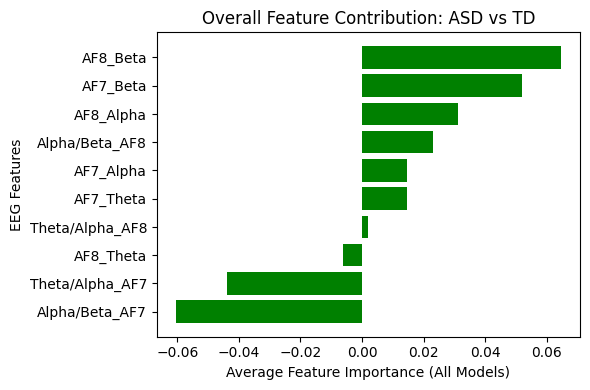

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

# Run permutation importance for each model
result_svm = permutation_importance(svm_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
result_knn = permutation_importance(knn_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
result_rf = permutation_importance(rf_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
result_ensemble = permutation_importance(ensemble_model, X_test_scaled, y_test, n_repeats=10, random_state=42)

# Extract average importance
importances_avg = np.mean([
    result_svm.importances_mean,
    result_knn.importances_mean,
    result_rf.importances_mean,
    result_ensemble.importances_mean
], axis=0)

# Plot the final combined feature importance
sorted_idx = importances_avg.argsort()
plt.figure(figsize=(6, 4))
plt.barh(X.columns[sorted_idx], importances_avg[sorted_idx], color='green')
plt.xlabel('Average Feature Importance (All Models)')
plt.ylabel('EEG Features')
plt.title('Overall Feature Contribution: ASD vs TD')
plt.tight_layout()
plt.show()


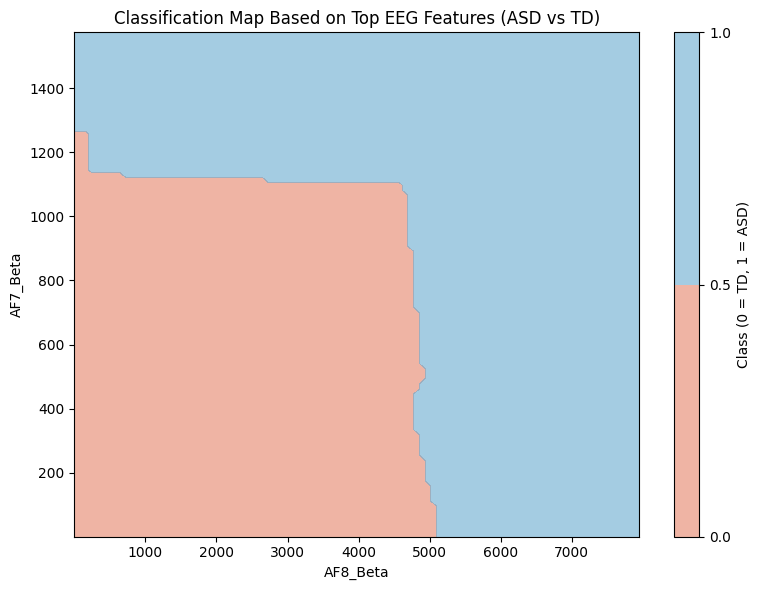

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose the model (use ensemble for best general performance)
model = ensemble_model

# Define feature names (must match column names)
feature_x = 'AF8_Beta'
feature_y = 'AF7_Beta'

# Create a meshgrid over feature ranges
x_range = np.linspace(X[feature_x].min(), X[feature_x].max(), 100)
y_range = np.linspace(X[feature_y].min(), X[feature_y].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)

# Create a grid of input data points
grid = pd.DataFrame({feature_x: xx.ravel(), feature_y: yy.ravel()})

# Add 0s for all other features to complete dimensionality
for col in X.columns:
    if col not in [feature_x, feature_y]:
        grid[col] = 0  # or grid[col] = X[col].mean() for smoother result

grid = grid[X.columns]  # Reorder columns to match original training data

# Scale the grid using the same scaler used before
grid_scaled = scaler.transform(grid)

# Predict class labels on the grid
Z = model.predict(grid_scaled)
Z = Z.reshape(xx.shape)

# Plot the classification map
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=1, cmap=plt.cm.RdBu, alpha=0.6)
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title('Classification Map Based on Top EEG Features (ASD vs TD)')
plt.colorbar(label='Class (0 = TD, 1 = ASD)')
plt.tight_layout()
plt.show()


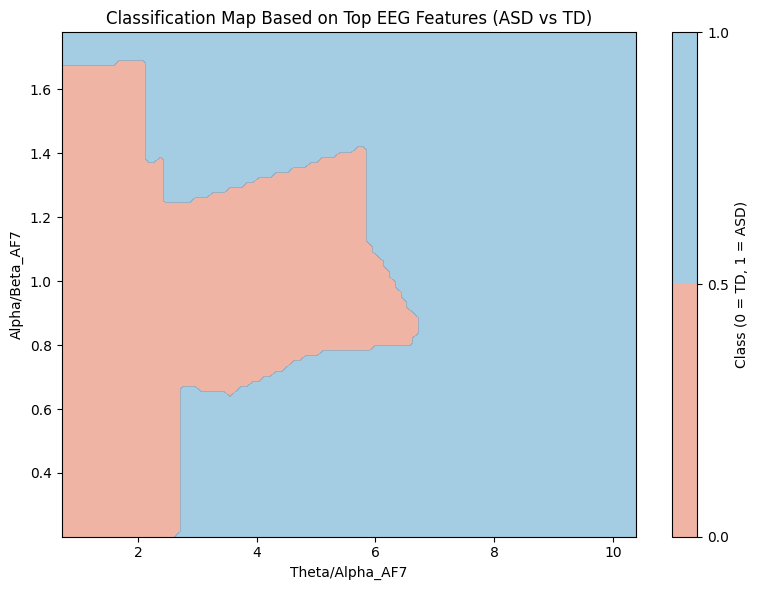

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose the model (use ensemble for best general performance)
model = ensemble_model

# Define feature names (must match column names)
feature_x = 'Theta/Alpha_AF7'
feature_y = 'Alpha/Beta_AF7'

# Create a meshgrid over feature ranges
x_range = np.linspace(X[feature_x].min(), X[feature_x].max(), 100)
y_range = np.linspace(X[feature_y].min(), X[feature_y].max(), 100)
xx, yy = np.meshgrid(x_range, y_range)

# Create a grid of input data points
grid = pd.DataFrame({feature_x: xx.ravel(), feature_y: yy.ravel()})

# Add 0s for all other features to complete dimensionality
for col in X.columns:
    if col not in [feature_x, feature_y]:
        grid[col] = 0  # or grid[col] = X[col].mean() for smoother result

grid = grid[X.columns]  # Reorder columns to match original training data

# Scale the grid using the same scaler used before
grid_scaled = scaler.transform(grid)

# Predict class labels on the grid
Z = model.predict(grid_scaled)
Z = Z.reshape(xx.shape)

# Plot the classification map
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=1, cmap=plt.cm.RdBu, alpha=0.6)
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title('Classification Map Based on Top EEG Features (ASD vs TD)')
plt.colorbar(label='Class (0 = TD, 1 = ASD)')
plt.tight_layout()
plt.show()
